In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [66]:
times_1923_04=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\timesheetReport_1923_042026.csv',sep=',')
utilization_1923_04=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\utilizationReport_1923_042026.csv',sep=',')
ars_1923_04=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\Activity Report_v3_es_1923_042026.csv',sep=',')
times_1923_04['Unidad_aux']='NaN'
utilization_1923_04['Unidad_aux']='NaN'
ars_1923_04['Unidad_aux']='NaN'
ars_1923_04['Miles_float']=0.0
times_1923_04.info()
utilization_1923_04.info()
ars_1923_04.info()


<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unidad                  14 non-null     str    
 1   Conductor               14 non-null     str    
 2   Fecha                   14 non-null     str    
 3   Ignición Encendido      14 non-null     str    
 4   Ignición Apagado        14 non-null     str    
 5   Dirección de Encendido  14 non-null     str    
 6   Dirección de Apagado    14 non-null     str    
 7   Tiempo                  14 non-null     str    
 8   Distancia (km)          14 non-null     float64
 9   Unidad_aux              14 non-null     str    
dtypes: float64(1), str(9)
memory usage: 1.2 KB
<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Etiqueta           

In [67]:
times_1923_04.groupby('Unidad').sum()

,Conductor,Fecha,Ignición Encendido,Ignición Apagado,Dirección de Encendido,Dirección de Apagado,Tiempo,Distancia (km),Unidad_aux
Unidad,,,,,,,,,
FSQ694,Conductor FSQ694Conductor FSQ694Conductor FSQ6...,19/04/202620/04/202621/04/202622/04/202623/04/...,19/04/202620/04/2026 4:27 AM21/04/2026 4:25 AM...,19/04/202620/04/2026 5:49 PM21/04/2026 5:24 PM...,"No ActivityCra. 145 # 145-20, Suba, Bogotá, D....","No ActivityCra. 145 #145, Bogotá, ColombiaCra....","23 hr, 59 min, 59 seg13 hr, 22 min, 35 seg12 h...",446.99,NaNNaNNaNNaNNaN
KYR910,Conductor KYR910Conductor KYR910Conductor KYR9...,20/04/202621/04/202622/04/202623/04/2026,20/04/2026 7:29 AM21/04/2026 7:27 AM22/04/2026...,20/04/2026 4:23 PM21/04/2026 8:54 PM22/04/2026...,"Cra. 25 #52b Sur-26, Bogotá, ColombiaCra. 5m #...","Cra 14 # 130-43, Usme, Bogotá, D.C., Bogotá, B...","8 hr, 54 min, 14 seg13 hr, 27 min, 0 seg9 hr, ...",189.96,NaNNaNNaNNaN
NOX568,Conductor NOX568Conductor NOX568Conductor NOX5...,19/04/202620/04/202621/04/202622/04/202623/04/...,19/04/2026 7:29 PM20/04/2026 4:43 AM21/04/2026...,19/04/2026 7:30 PM20/04/2026 9:05 PM21/04/2026...,"Cl. 47 Sur #1 - 11, Bogotá, ColombiaCl. 47 Sur...","Cl. 47 Sur #1 - 11, Bogotá, ColombiaCl. 47 Sur...","1 min, 8 seg16 hr, 22 min, 11 seg12 hr, 44 min...",707.23,NaNNaNNaNNaNNaN


In [68]:
utilization_1923_04.groupby('Unidad').sum()

,Etiqueta,Conductor,Distancia (km),Duración,Tiempo en Inactividad,Tiempo de Parada,Porcentaje en Movimiento,Días Trabajados,Días Totales,Porcentaje de Días,Unidad_aux
Unidad,,,,,,,,,,,
FSQ694,ORT,Conductor FSQ694,447.02,"20 hr, 28 min, 40 seg","9 hr, 2 min, 55 seg","3 días, 18 hr, 28 min, 25 seg",22.63%,4,5,80.00%,NaN
KYR910,ORT,Conductor KYR910,219.29,"5 hr, 33 min, 45 seg","2 hr, 5 min, 27 seg","3 días, 8 hr, 51 min, 30 seg",6.88%,4,5,80.00%,NaN
NOX568,ORT,Conductor NOX568,706.96,"19 hr, 4 min, 7 seg","6 hr, 16 min, 23 seg","3 días, 22 hr, 39 min, 30 seg",20.14%,5,5,100.00%,NaN


In [69]:
cad=[]
for i in range(0, ars_1923_04.shape[0]):
    try:
        aux=ars_1923_04.iloc[i,4].replace(',','.')
        cad.append(float(aux))
    except AttributeError as e:
        print("Troubles with report: ",ars_1923_04.iloc[i,2]," Unit:",ars_1923_04.iloc[i,1])
        ars_1923_04.iloc[i,4]='222222222'
        cad.append(0)

ars_1923_04['Miles_float']=cad

Troubles with report:  20/04/2026 7:06 a.m.  Unit: Unidad: KYR910
Troubles with report:  20/04/2026 7:17 a.m.  Unit: Unidad: KYR910
Troubles with report:  20/04/2026 8:02 a.m.  Unit: Unidad: KYR910
Troubles with report:  20/04/2026 11:11 a.m.  Unit: Unidad: KYR910
Troubles with report:  20/04/2026 2:27 p.m.  Unit: Unidad: KYR910
Troubles with report:  20/04/2026 6:07 p.m.  Unit: Unidad: KYR910
Troubles with report:  21/04/2026 11:34 a.m.  Unit: Unidad: KYR910
Troubles with report:  22/04/2026 8:35 a.m.  Unit: Unidad: KYR910
Troubles with report:  22/04/2026 12:17 p.m.  Unit: Unidad: KYR910
Troubles with report:  23/04/2026 8:51 a.m.  Unit: Unidad: KYR910


In [70]:
ars_1923_04.groupby('UnitName').sum()

,GroupName,StartTime,MovingTimeSecs,MilesDriven,MaxSpeed,StopTime,textbox43,StopLengthSecs,ContactName,textbox28,textbox29,textbox30,textbox32,MovingTimeSecs_1,MilesDriven_1,MaxSpeed_1,StopLengthSecs_1,Unidad_aux,Miles_float
UnitName,,,,,,,,,,,,,,,,,,,
Unidad: FSQ694,0.0,19/04/2026 12:00 a.m.20/04/2026 4:34 a.m.20/04...,00h:00m:00s00h:05m:41s00h:05m:11s00h:04m:01s00...,"0,001,111,350,480,640,450,231,752,690,475,170,...",4724,20/04/2026 4:27:1.m.20/04/2026 4:40:1.m.20/04/...,Denido/RalentiRalentiRalentiRalentiRalentiRale...,28h:33m:31s00h:04m:49s00h:01m:59s00h:01m:00s00...,"Kr145 145-20, Bogota, Cundinamarca, ColombiaCl...",20h:51m:19s20h:51m:19s20h:51m:19s20h:51m:19s20...,"446,98446,98446,98446,98446,98446,98446,98446,...",13590,103h:24m:45s103h:24m:45s103h:24m:45s103h:24m:4...,53h:02m:32s53h:02m:32s53h:02m:32s53h:02m:32s53...,"1.348,781.348,781.348,781.348,781.348,781.348,...",14798,323h:14m:26s323h:14m:26s323h:14m:26s323h:14m:2...,NaNNaNNaNNaNNaNNaNNaNNaNNaNNaNNaNNaNNaNNaNNaNN...,446.91
Unidad: KYR910,0.0,19/04/2026 12:00 a.m.20/04/2026 7:06 a.m.20/04...,00h:00m:00s00h:06m:10s00h:00m:00s00h:04m:08s00...,"0,002222222220,002222222221,900,000,680,610,00...",2861,20/04/2026 7:05:5.m.20/04/2026 7:12:2.m.20/04/...,Denido/RalentiIgnición ApagadaDenido/RalentiRa...,31h:05m:55s00h:04m:09s00h:00m:00s00h:01m:06s00...,"Cl49s 5n-40, Bogota, Cundinamarca, ColombiaKr1...",11h:38m:53s11h:38m:53s11h:38m:53s11h:38m:53s11...,"194,88194,88194,88194,88194,88194,88194,88194,...",11340,115h:40m:48s115h:40m:48s115h:40m:48s115h:40m:4...,53h:02m:32s53h:02m:32s53h:02m:32s53h:02m:32s53...,"1.348,781.348,781.348,781.348,781.348,781.348,...",12348,323h:14m:26s323h:14m:26s323h:14m:26s323h:14m:2...,NaNNaNNaNNaNNaNNaNNaNNaNNaNNaNNaNNaNNaNNaNNaNN...,194.88
Unidad: NOX568,0.0,19/04/2026 12:00 a.m.19/04/2026 7:29 p.m.20/04...,00h:00m:00s00h:00m:00s00h:00m:00s00h:10m:04s00...,"0,000,000,004,650,110,001,858,590,000,982,271,...",3047,19/04/2026 7:15:5.m.19/04/2026 7:29:3.m.20/04/...,Denido/RalentiDenido/RalentiDenido/RalentiRale...,19h:34m:55s09h:14m:11s00h:06m:55s00h:00m:25s00...,"Cl. 47 Sur #1-1 a 1-15, Bogotá, Bogotá, Colomb...",20h:32m:20s20h:32m:20s20h:32m:20s20h:32m:20s20...,"706,92706,92706,92706,92706,92706,92706,92706,...",10045,104h:08m:53s104h:08m:53s104h:08m:53s104h:08m:5...,53h:02m:32s53h:02m:32s53h:02m:32s53h:02m:32s53...,"1.348,781.348,781.348,781.348,781.348,781.348,...",10045,323h:14m:26s323h:14m:26s323h:14m:26s323h:14m:2...,NaNNaNNaNNaNNaNNaNNaNNaNNaNNaNNaNNaNNaNNaNNaNN...,706.93


In [71]:
raw_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\kyr910.csv',sep=',',encoding='latin1')
raw_datam=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\kyr910_columns.csv',sep=',',encoding='latin1')
raw_datam.rename(columns={'Unnamed: 1':'Message Type',
                                 'Unnamed: 2':'Protocole',
                                 'Unnamed: 3':'IMEI',
                                 'Unnamed: 4':'Serial',
                                 'Unnamed: 5':'Mileage',
                                 'Unnamed: 6':'Date',
                                 'Unnamed: 7':'Ignition',
                                 'Unnamed: 8':'Latitude',
                                 'Unnamed: 9':'Longitude',
                                 'Unnamed: 10':'Altitude',
                                 'Unnamed: 11':'External Power',
                                 'Unnamed: 12':'RPM',
                                 'Unnamed: 13':'Speed',
                                 'Unnamed: 14':'Satellite Number',
                                 'Unnamed: 15':'Azimuth',
                                 'Unnamed: 16':'Bettery level',
                                 },inplace=True)
raw_datam.info()
raw_datam.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\kyr910_m.csv')

<class 'pandas.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Message           256 non-null    str  
 1   Message Type      256 non-null    str  
 2   Protocole         256 non-null    str  
 3   IMEI              256 non-null    str  
 4   Serial            256 non-null    str  
 5   Mileage           256 non-null    str  
 6   Date              256 non-null    str  
 7   Ignition          256 non-null    str  
 8   Latitude          256 non-null    str  
 9   Longitude         256 non-null    str  
 10  Altitude          256 non-null    str  
 11  External Power    236 non-null    str  
 12  RPM               236 non-null    str  
 13  Speed             217 non-null    str  
 14  Satellite Number  217 non-null    str  
 15  Azimuth           217 non-null    str  
 16  Bettery level     217 non-null    str  
dtypes: str(17)
memory usage: 34.1 KB


In [72]:
unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\kyr910_m.csv',sep=',')
unit['Odometer in meters']=0.0
unit.info()
unit_mileage=unit[unit['Date'].str.contains('2026-04-20')]
unit_mileage[['Mileage','Date','IMEI']]

<class 'pandas.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          256 non-null    int64  
 1   Message             256 non-null    str    
 2   Message Type        256 non-null    str    
 3   Protocole           256 non-null    str    
 4   IMEI                256 non-null    str    
 5   Serial              256 non-null    str    
 6   Mileage             256 non-null    str    
 7   Date                256 non-null    str    
 8   Ignition            256 non-null    str    
 9   Latitude            256 non-null    str    
 10  Longitude           256 non-null    str    
 11  Altitude            256 non-null    str    
 12  External Power      236 non-null    str    
 13  RPM                 236 non-null    str    
 14  Speed               217 non-null    str    
 15  Satellite Number    217 non-null    str    
 16  Azimuth            

,Mileage,Date,IMEI
9,Mileage:3835363,"Date:""2026-04-20T12:05:55Z""","Imei:""869487064469157"""
10,Mileage:3835423,"Date:""2026-04-20T12:06:16Z""","Imei:""869487064469157"""
11,Mileage:3835688,"Date:""2026-04-20T12:06:51Z""","Imei:""869487064469157"""
12,Mileage:3835934,"Date:""2026-04-20T12:07:33Z""","Imei:""869487064469157"""
13,Mileage:3835952,"Date:""2026-04-20T12:07:37Z""","Imei:""869487064469157"""
...,...,...,...
251,Mileage:3879591,"Date:""2026-04-20T23:55:51Z""","Imei:""869487064469157"""
252,Mileage:3879630,"Date:""2026-04-20T23:56:52Z""","Imei:""869487064469157"""
253,Mileage:3879659,"Date:""2026-04-20T23:57:52Z""","Imei:""869487064469157"""
254,Mileage:3879659,"Date:""2026-04-20T23:58:52Z""","Imei:""869487064469157"""


In [73]:
unit_odometer=unit[~unit['Protocole'].str.contains(':0')]
unit_odometer['Protocole'].value_counts()

Protocole
ProtocolHeadType:19    186
ProtocolHeadType:20     31
Name: count, dtype: int64

Delta odometer:  5639.0 meters
Date:"2000-01-01T00:00:05Z"  ->  0 3835231.0
Date:"2026-04-20T12:05:55Z"  ->  1 3835363.0
Date:"2026-04-20T12:06:16Z"  ->  2 3835423.0
Date:"2026-04-20T12:06:51Z"  ->  3 3835688.0
Date:"2026-04-20T12:07:33Z"  ->  4 3835934.0
Date:"2026-04-20T12:07:37Z"  ->  5 3835952.0
Date:"2026-04-20T12:08:05Z"  ->  6 3836123.0
Date:"2026-04-20T12:09:51Z"  ->  7 3836565.0
Date:"2026-04-20T12:10:25Z"  ->  8 3836649.0
Date:"2026-04-20T12:11:04Z"  ->  9 3836946.0
Date:"2026-04-20T12:11:56Z"  ->  10 3837348.0
Date:"2026-04-20T12:12:26Z"  ->  11 3837364.0
Date:"2000-01-01T00:00:05Z"  ->  12 3837364.0
Date:"2026-04-20T12:16:35Z"  ->  13 3837609.0
Date:"2026-04-20T12:17:28Z"  ->  14 3838084.0
Date:"2026-04-20T12:18:36Z"  ->  15 3838610.0
Date:"2026-04-20T12:19:13Z"  ->  16 3838824.0
Date:"2026-04-20T12:19:34Z"  ->  17 3838919.0
Date:"2026-04-20T12:19:44Z"  ->  18 3838966.0
Date:"2026-04-20T12:20:34Z"  ->  19 3839261.0
Date:"2026-04-20T12:21:36Z"  ->  20 3839279.0
Date:"2026-04

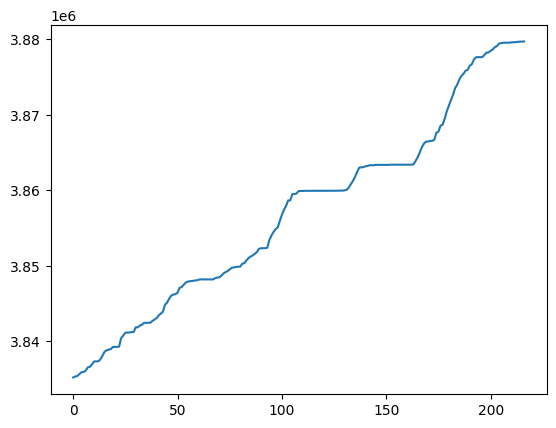

In [75]:
y_axis=[]
x_axis=[]
date=[]

for i in range(0,unit_odometer.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit_odometer.iloc[i,6][8:15]))
    x_axis.append(i)
    date.append(unit_odometer.iloc[i,7])

print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,171):
    print(date[i],' -> ',x_axis[i],y_axis[i])

"""
plt.ylim(5230627,5240177)
plt.xlim(133,171)
plt.yticks(range(5230627,5240177,500))
plt.xticks(range(133,171,5),rotation=90)
"""
plt.plot(x_axis,y_axis)